In [51]:
import numpy as np

In [52]:
# First we understand the hopfield network - where we had no input , hidden or output layers.
# Every neuron was connected to every other neuron;no gradients-here we store binary memories

# Simply what this experiment gave us was the concept of state - a memory used to store the computations done before that affect future decisions

In [53]:
# First store a pattern in an array
pattern = np.array([1, 1, -1, -1, 1, 1, -1, -1])

# The neuroms with value 1 are in ON state and one with -1 are in OFF state.
# This whole setup is based on only one concept : " Neurons that fire together wire together."

In [54]:
# Here every neuron is connected to each other
n_neurons = len(pattern)
# We here instantiate n_neurons where each neuron is carring a single pattern value

In [55]:
# We follow a hebbian learning approach :
W = np.outer(pattern,pattern) # we compute the outer product between the own matrix
# You can imagine outer product as creating a new vector strip pattern for each i value multiplied from our pattern and then stacking them up.

# A neuron should not vote for itself so diagonals are zero.
np.fill_diagonal(W,0)

In [56]:
W
# These values are the relation between each neuron.
# We need matrix as it is the only way we can describe the relation between neurons with each other
# The positive connections are such connections where both the neurons agree (both 1 or 0) and
# There is no self relation in neurons so diagonal elements are made zero

array([[ 0,  1, -1, -1,  1,  1, -1, -1],
       [ 1,  0, -1, -1,  1,  1, -1, -1],
       [-1, -1,  0,  1, -1, -1,  1,  1],
       [-1, -1,  1,  0, -1, -1,  1,  1],
       [ 1,  1, -1, -1,  0,  1, -1, -1],
       [ 1,  1, -1, -1,  1,  0, -1, -1],
       [-1, -1,  1,  1, -1, -1,  0,  1],
       [-1, -1,  1,  1, -1, -1,  1,  0]])

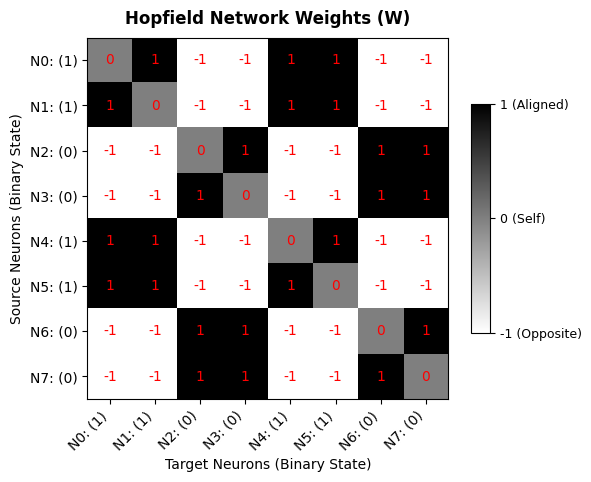

In [57]:
# This below is a simple code I fetched to visualize the relationships between each neuron
import matplotlib.pyplot as plt
import numpy as np

binary_labels = [f"N{i}: ({1 if state == 1 else 0})" for i, state in enumerate(pattern)]

plt.figure(figsize=(6, 5))
plt.imshow(W, cmap='binary', interpolation='nearest', vmin=-1, vmax=1)

for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        plt.text(j, i, str(W[i, j]), ha="center", va="center", color="red")

plt.title('Hopfield Network Weights (W)', fontsize=12, pad=10, fontweight='bold')
plt.xlabel('Target Neurons (Binary State)', fontsize=10)
plt.ylabel('Source Neurons (Binary State)', fontsize=10)

plt.xticks(np.arange(W.shape[1]), binary_labels, rotation=45, ha='right')
plt.yticks(np.arange(W.shape[0]), binary_labels)

cbar = plt.colorbar(ticks=[-1, 0, 1], shrink=0.6, aspect=12)
cbar.ax.set_yticklabels(['-1 (Opposite)', '0 (Self)', '1 (Aligned)'], fontsize=9)

plt.tight_layout()
plt.show()


In [58]:
# Now we create a corrupt version of our original pattern
corrupt_pattern = np.array([1, -1, -1, -1, 1, 1, 1, 1])
# Think of this as some lost information in the original pattern

In [59]:
# Now we run a reccurent loop where we try to restore the orginal pattern

# Declare the state variable
state = corrupt_pattern.copy().astype(float)

# We have the current copy of the pattern copied to state as float
# Float as we have numeric computations converting these values to float

In [60]:
# Let's run the loop :
for iteration in range(10):
    # STEP 1: Pick a neuron
    idx = np.random.randint(0, n_neurons)

    # STEP 2: Gather incoming votes
    total_pull = np.dot(W[idx], state)

    # STEP 3: Make the final decision
    state[idx] = 1 if total_pull >= 0 else -1

    print(f'Step {iteration} | Index : {idx} |total pull : {total_pull}  | {W[idx]}--->{state}')

    # STEP 4: Check if done
    if np.array_equal(state, pattern):
        break

Step 0 | Index : 2 |total pull : -1.0  | [-1 -1  0  1 -1 -1  1  1]--->[ 1. -1. -1. -1.  1.  1.  1.  1.]
Step 1 | Index : 5 |total pull : 1.0  | [ 1  1 -1 -1  1  0 -1 -1]--->[ 1. -1. -1. -1.  1.  1.  1.  1.]
Step 2 | Index : 7 |total pull : -3.0  | [-1 -1  1  1 -1 -1  1  0]--->[ 1. -1. -1. -1.  1.  1.  1. -1.]
Step 3 | Index : 3 |total pull : -3.0  | [-1 -1  1  0 -1 -1  1  1]--->[ 1. -1. -1. -1.  1.  1.  1. -1.]
Step 4 | Index : 4 |total pull : 3.0  | [ 1  1 -1 -1  0  1 -1 -1]--->[ 1. -1. -1. -1.  1.  1.  1. -1.]
Step 5 | Index : 2 |total pull : -3.0  | [-1 -1  0  1 -1 -1  1  1]--->[ 1. -1. -1. -1.  1.  1.  1. -1.]
Step 6 | Index : 5 |total pull : 3.0  | [ 1  1 -1 -1  1  0 -1 -1]--->[ 1. -1. -1. -1.  1.  1.  1. -1.]
Step 7 | Index : 4 |total pull : 3.0  | [ 1  1 -1 -1  0  1 -1 -1]--->[ 1. -1. -1. -1.  1.  1.  1. -1.]
Step 8 | Index : 2 |total pull : -3.0  | [-1 -1  0  1 -1 -1  1  1]--->[ 1. -1. -1. -1.  1.  1.  1. -1.]
Step 9 | Index : 1 |total pull : 5.0  | [ 1  0 -1 -1  1  1 -1 -1]---

In [61]:
# How does this even work ?

# See the rule is simple if for a given index of the neuron the index values for each column matches then the dot product is to be 0.
# If the values disagree then the dot product is to be negative.
# So what we are trying to do in each step is to simply retain some prev state and restore to actual value

# This is the magic of hebbian learning which is based on the principle : "Neurons that fire together fire together."
# It is based on the fact that the disagreeing neurons are stored as -1 and agreeing one as 1.
# Based on the pole priniple.

In [62]:
# state
state


array([ 1.,  1., -1., -1.,  1.,  1.,  1., -1.])